In [2]:
from utils_activations import *
from utils_syn_classifying import *
from utils import makefolder

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


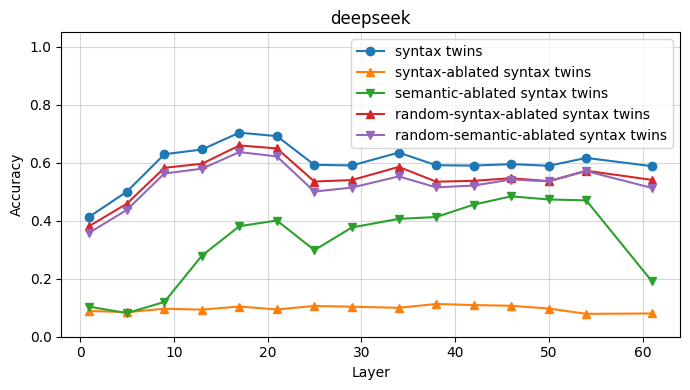

In [4]:
import numpy as np
import matplotlib.pyplot as plt

model_name = 'deepseek'
avg_tokens = 0
normalization_flag = 1
shuffled_controls = [0,1]

plt.figure(figsize=(7, 4))

for shuffled_control_id,shuffled_control in enumerate(shuffled_controls):
    resultsfolder = makefolder(base='./results/syntax_classification/',
                           model_name=model_name,
                           avg_tokens=avg_tokens,
                           normalization_flag=normalization_flag,
                           shuffled_control=shuffled_control,
                           )

    results = np.load(resultsfolder+'results.npz')

    layer_indices   = results['layer_indices']
    accs_A = results['accs_A']
    accs_B = results['accs_B']
    syn_ablated_accs_A  = results['syn_ablated_accs_A']
    syn_ablated_accs_B  = results['syn_ablated_accs_B']
    sem_ablated_accs_A  = results['sem_ablated_accs_A']
    lambda_l2       = results['lambda_l2']

    if shuffled_control == 0:
        plt.plot(layer_indices, accs_A,   marker='o', label='syntax twins')
        # plt.plot(layer_indices, accs_B,    marker='s', label='B (train)')
        aux = ''
    else:
        aux = 'random-'    
    plt.plot(layer_indices, syn_ablated_accs_A, marker='^', label=f'{aux}syntax-ablated syntax twins')
    # plt.plot(layer_indices, syn_ablated_accs_B, marker='v', label=f'syntax-ablated B')
    plt.plot(layer_indices, sem_ablated_accs_A, marker='v', label=f'{aux}semantic-ablated syntax twins')

    plt.xlabel("Layer")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.05)
    title = f"{model_name}"
    plt.title(title)
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.tight_layout()
plt.show()

In [ ]:
### Dependence on the amount of training data

lambda_l2 = 10
fractions = [ 1.0]

N = act_A.shape[0]
assert act_B.shape[0] == N
assert training_labels.shape[0] == N

test_labels = training_labels  # same ordering for act_B

base_key = jax.random.PRNGKey(42)

train_accs = []
test_accs = []
Ws_list = []

for i, frac in enumerate(fractions):
    n_train = int(frac * N)

    # Random subset of indices for this fraction
    key = jax.random.fold_in(base_key, i)
    perm = jax.random.permutation(key, N)
    train_idx = perm[:n_train]

    X_train = act_A[train_idx]          # (n_train, D)
    y_train = training_labels[train_idx]

    # Fit linear classifier with fixed L2 = 1.0
    W = fit_linear_classifier_closed_form(
        X_train,
        y_train,
        num_classes=None,
        l2_reg=lambda_l2,
        add_bias=True,
    )

    # Accuracy on the training subset only
    train_acc = accuracy(X_train, y_train, W, add_bias=True)

    # Accuracy on the test set (act_B, same labels)
    test_acc = accuracy(act_B, test_labels, W, add_bias=True)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    Ws_list.append(W)

    print(
        f"fraction={frac:.1f}, "
        f"n_train={n_train}, "
        f"train_acc={float(train_acc):.3f}, "
        f"test_acc={float(test_acc):.3f}"
    )

train_accs = jnp.stack(train_accs)        # (5,)
test_accs = jnp.stack(test_accs)          # (5,)
Ws = jnp.stack(Ws_list)                   # (5, D_eff, C)
fractions = jnp.array(fractions)          # (5,)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert from JAX to NumPy if needed
fracs = np.asarray(fractions)
train = np.asarray(train_accs)
test  = np.asarray(test_accs)

plt.figure(figsize=(6, 4))

# Lines + markers
plt.plot(fracs, train, marker='o', label='Train accuracy')
plt.plot(fracs, test,  marker='s', label='Test accuracy (act_B)')

# Slightly emphasize the scatter points
plt.scatter(fracs, train, alpha=0.9)
plt.scatter(fracs, test,  alpha=0.9)

plt.xlabel("Training fraction")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.title("Dependence of accuracy on training set size")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
### Dependence on L2 regularization

l2_values = jnp.logspace(-1, 2, num=10)  # e.g. 1e-6 ... 1e3
acc_A, W_A = sweep_l2_regularization(
                                    act_A,
                                    training_labels,
                                    l2_values,
                                    add_bias=True,
                                )

# Validation: accuracy of W_A (trained on act_A) evaluated on act_B
val_acc_B_from_WA = accuracies_from_Ws(
    act_B,
    training_labels,   # or your dedicated val labels if you have them
    W_A,
    add_bias=True,
)

l2_vals_np = np.array(l2_values)
acc_A_np = np.array(acc_A)
val_B_np = np.array(val_acc_B_from_WA)

plt.figure()
plt.semilogx(l2_vals_np, acc_A_np, marker='o', label="train on A (A→A)")
plt.semilogx(l2_vals_np, val_B_np, marker='o', linestyle='--', label="val on B (A→B)")

plt.xlabel("L2 regularization λ")
plt.ylabel("Accuracy")
plt.title("Accuracy vs L2: train on A, validate on B")
plt.grid(True, which="both", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# acc_B, W_B = sweep_l2_regularization(
#                                     act_B,
#                                     training_labels,
#                                     l2_values,
#                                     add_bias=True,
#                                 )

In [ ]:


plt.figure(figsize=(7, 4))

plt.plot(layer_indices, train_norm_accs_A,   marker='o', label='Train A (norm)')
plt.plot(layer_indices, test_norm_accs_B,    marker='s', label='Test B (norm)')
plt.plot(layer_indices, ablated_norm_accs_A, marker='^', label='A ablated (norm)')
plt.plot(layer_indices, ablated_norm_accs_B, marker='v', label='B ablated (norm)')

plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.05)
plt.title(f"Layer dependence (L2-normalized features) – {model_name}")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()